<a href="https://colab.research.google.com/github/JosNavarro/Invest2026-27/blob/main/GRUVanilla.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import gc
import scipy.io as sio
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from torch.utils.data import TensorDataset, DataLoader

# ==========================================
# CONFIGURACIÓN INICIAL
# ==========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
battery_id = 'B0005'

from google.colab import drive
drive.mount('/content/drive')


# Ruta donde subiste el archivo generado por MATLAB
route_datos_colab = '/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/'
data_path = f'{route_datos_colab}{battery_id}ready.mat'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

# Define the directory path
directory_path = Path('/content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions/')

# Verify if the directory exists
if directory_path.is_dir():
    print(f"Contents of {directory_path}:")

    # Iterate through the directory
    for item in directory_path.iterdir():
        print(f" - {item.name} ({'File' if item.is_file() else 'Directory'})")
else:
    print("The specified path is not a valid directory.")

Contents of /content/drive/My Drive/PI26/NASADATASET/1. BatteryAgingARC-FY08Q4/ChargePartitions:
 - B0005ready.mat (File)
 - B0006ready.mat (File)


In [ ]:
# ==========================================
# 1. CARGA DE TENSORES PRE-PROCESADOS (70/15/15)
# ==========================================
print(f"1. CARGANDO TENSORES IDENTICOS DESDE MATLAB ({battery_id})...")
mat_data = sio.loadmat(data_path)

X_train_tensor = torch.tensor(mat_data['X_train_mat'], dtype=torch.float32)
Y_train_tensor = torch.tensor(mat_data['Y_train_mat'], dtype=torch.float32).view(-1, 1)

X_val_tensor = torch.tensor(mat_data['X_val_mat'], dtype=torch.float32)
Y_val_tensor = torch.tensor(mat_data['Y_val_mat'], dtype=torch.float32).view(-1, 1)

X_test_tensor = torch.tensor(mat_data['X_test_mat'], dtype=torch.float32)
Y_test_tensor = torch.tensor(mat_data['Y_test_mat'], dtype=torch.float32).view(-1, 1)

cap_inicial_real = mat_data['capacidad_inicial'][0][0]

print(f"-> Train (70%): {X_train_tensor.shape}")
print(f"-> Val   (15%): {X_val_tensor.shape}")
print(f"-> Test  (15%): {X_test_tensor.shape}")

train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

1. CARGANDO TENSORES IDENTICOS DESDE MATLAB (B0005)...
-> Train (70%): torch.Size([35165, 50, 7])
-> Val   (15%): torch.Size([7535, 50, 7])
-> Test  (15%): torch.Size([7536, 50, 7])


In [ ]:
# ==========================================
# 2. ARQUITECTURA GRU VANILLA (Misma base sin parámetros físicos)
# ==========================================
class Vanilla_AGRU(nn.Module):
    def __init__(self, input_size=7, hidden_size=128, num_layers=2, output_size=1):
        super(Vanilla_AGRU, self).__init__()
        # Misma estructura de red para una comparación justa
        self.gru = nn.GRU(input_size, hidden_size, num_layers, batch_first=True, dropout=0.05)
        self.attention = nn.Linear(hidden_size, 1)
        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        gru_out, _ = self.gru(x)
        attn_scores = self.attention(gru_out)
        attn_weights = F.softmax(attn_scores, dim=1)
        context_vector = torch.sum(gru_out * attn_weights, dim=1)

        # ELIMINAMOS EL SIGMOIDE. Dejamos que la red prediga libremente.
        prediction = self.fc(context_vector)
        return prediction

In [ ]:
# ==========================================
# 3. BUCLE DE ENTRENAMIENTO PURE DATA-DRIVEN
# ==========================================
print("\n2. INICIANDO ENTRENAMIENTO GRU VANILLA (Aceleración CuDNN Completa)...")
model = Vanilla_AGRU(input_size=7).to(device)

num_epochs = 50
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=20, gamma=0.5)

# Detección automática de hardware para el escalador
device_type = 'cuda' if torch.cuda.is_available() else 'cpu'
es_gpu = (device_type == 'cuda')
scaler = torch.amp.GradScaler(device_type) if es_gpu else None

for epoch in range(num_epochs):
    model.train()
    epoch_loss_data = 0.0

    for batch_X, batch_Y in train_loader:
        batch_X = batch_X.to(device)
        batch_Y = batch_Y.to(device)
        optimizer.zero_grad()

        # Al ser Vanilla, CUDNN está activo por defecto (Máxima velocidad)
        with torch.amp.autocast(device_type=device_type, enabled=es_gpu):
            predictions = model(batch_X)
            loss = criterion(predictions, batch_Y) * 100.0

        if es_gpu:
            scaler.scale(loss).backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=0.1)
            optimizer.step()

        epoch_loss_data += loss.item()

    scheduler.step()

    # --- FASE DE VALIDACIÓN ---
    model.eval()
    with torch.no_grad():
        val_X = X_val_tensor.to(device)
        val_Y = Y_val_tensor.to(device)
        val_preds = model(val_X)
        val_loss = criterion(val_preds, val_Y).item()

    if (epoch + 1) % 5 == 0 or epoch == 0:
        avg_train_loss = epoch_loss_data / len(train_loader)
        print(f'Epoch [{epoch+1:02d}/{num_epochs}] | Train MSE: {avg_train_loss:.5f} | Val MSE: {val_loss:.5f}')


2. INICIANDO ENTRENAMIENTO GRU VANILLA (Aceleración CuDNN Completa)...
Epoch [01/50] | Train MSE: 8.47712 | Val MSE: 0.00014
Epoch [05/50] | Train MSE: 0.11857 | Val MSE: 0.00030
Epoch [10/50] | Train MSE: 0.05406 | Val MSE: 0.00414
Epoch [15/50] | Train MSE: 0.04542 | Val MSE: 0.00038
Epoch [20/50] | Train MSE: 0.02733 | Val MSE: 0.00026
Epoch [25/50] | Train MSE: 0.02197 | Val MSE: 0.00040
Epoch [30/50] | Train MSE: 0.01635 | Val MSE: 0.00035
Epoch [35/50] | Train MSE: 0.01635 | Val MSE: 0.00026
Epoch [40/50] | Train MSE: 0.01999 | Val MSE: 0.00025
Epoch [45/50] | Train MSE: 0.01580 | Val MSE: 0.00031
Epoch [50/50] | Train MSE: 0.01543 | Val MSE: 0.00016


In [ ]:
# ==========================================
# 4. EVALUACIÓN (Testing / Pronóstico a Ciegas)
# ==========================================
torch.cuda.empty_cache()
gc.collect()

print("\n3. EVALUANDO EL 15% FUTURO DE LA BATERÍA (TESTING)...")
model.eval()
with torch.no_grad():
    test_preds = model(X_test_tensor.to(device)).cpu().numpy().flatten()
    actual_test_soh = Y_test_tensor.numpy().flatten()

test_mse = mean_squared_error(actual_test_soh, test_preds)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(actual_test_soh, test_preds)
test_r2 = r2_score(actual_test_soh, test_preds)

print("-" * 40)
print(f"REPORTE DE RENDIMIENTO VANILLA: Batería {battery_id}")
print("-" * 40)
print(f"RMSE: {test_rmse:.6f} (SoH)")
print(f"MAE:  {test_mae:.6f} (SoH)")
print(f"R^2:  {test_r2:.4f}")
print("-" * 40)


3. EVALUANDO EL 15% FUTURO DE LA BATERÍA (TESTING)...
----------------------------------------
REPORTE DE RENDIMIENTO VANILLA: Batería B0005
----------------------------------------
RMSE: 0.043053 (SoH)
MAE:  0.040846 (SoH)
R^2:  -22.4033
----------------------------------------


Generando predicciones completas para la gráfica (en lotes)...


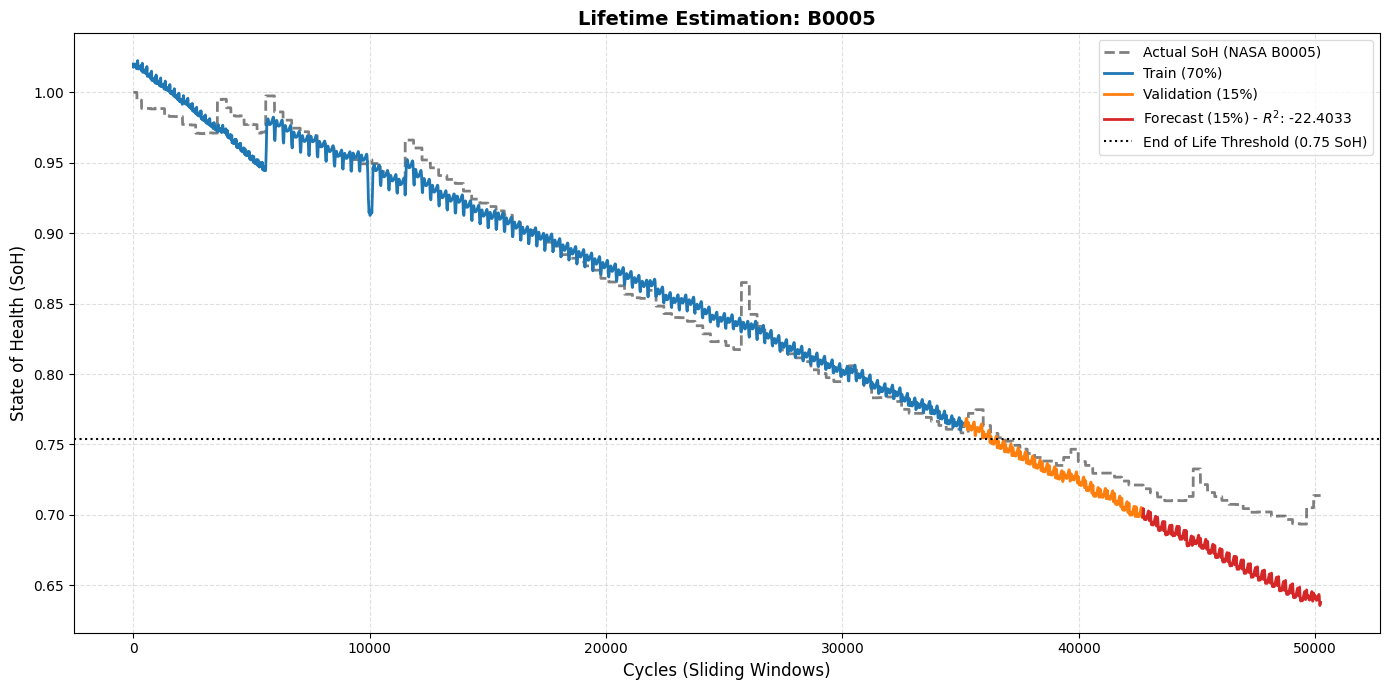

In [ ]:
# ==========================================
# 5. VISUALIZACIÓN PANORÁMICA COMPARATIVA
# ==========================================
# Liberar cualquier residuo en la memoria de la GPU
torch.cuda.empty_cache()
gc.collect()

print("Generando predicciones completas para la gráfica (en lotes)...")

with torch.no_grad():
    # Unimos los tensores pero los dejamos en el CPU temporalmente
    X_full = torch.cat([X_train_tensor, X_val_tensor, X_test_tensor], dim=0)
    Y_full = torch.cat([Y_train_tensor, Y_val_tensor, Y_test_tensor], dim=0).numpy().flatten()

    # Evaluar en lotes pequeños para no desbordar la memoria CUDA
    all_full_preds = []
    batch_size_grafica = 256

    for i in range(0, len(X_full), batch_size_grafica):
        # Movemos solo un pequeño lote a la GPU
        batch_X = X_full[i : i + batch_size_grafica].to(device)
        batch_preds = model(batch_X)
        # Lo devolvemos al CPU inmediatamente
        all_full_preds.append(batch_preds.cpu().numpy())

    # Juntamos los pedazos
    full_preds = np.concatenate(all_full_preds, axis=0).flatten()

# --- Creación de la Gráfica ---
fig, ax = plt.subplots(figsize=(14, 7))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Trayectoria real completa de fondo
ax.plot(Y_full, label=f'Actual SoH (NASA {battery_id})', color='black', alpha=0.5, linewidth=2, linestyle='--')

# Separación por fases indexadas cronológicamente
len_tr = len(X_train_tensor)
len_val = len(X_val_tensor)
len_ts = len(X_test_tensor)

# Curvas de predicción por zona
ax.plot(range(0, len_tr), full_preds[:len_tr], label='Train (70%)', color='#1f77b4', linewidth=2)
ax.plot(range(len_tr, len_tr+len_val), full_preds[len_tr:len_tr+len_val], label='Validation (15%)', color='#ff7f0e', linewidth=2)
ax.plot(range(len_tr+len_val, len_tr+len_val+len_ts), full_preds[len_tr+len_val:], label=f'Forecast (15%) - $R^2$: {test_r2:.4f}', color='#d62728', linewidth=2)

# Límite técnico convencional (1.4 Ah convertido a SoH)
eol_soh = 1.4 / cap_inicial_real
ax.axhline(y=eol_soh, color='black', linestyle=':', label=f'End of Life Threshold ({eol_soh:.2f} SoH)')

ax.set_title(f'Lifetime Estimation: {battery_id}', color='black', fontsize=14, fontweight='bold')
ax.set_xlabel('Cycles (Sliding Windows)', color='black', fontsize=12)
ax.set_ylabel('State of Health (SoH)', color='black', fontsize=12)
ax.tick_params(colors='black')
ax.legend(facecolor='white', edgecolor='lightgray', labelcolor='black')
ax.grid(True, linestyle='--', color='silver', alpha=0.5)

for spine in ax.spines.values():
    spine.set_edgecolor('black')

plt.tight_layout()
plt.show()
